# Cross-Domain Benchmark Notebook

This notebook is designed to fill **deficiency D002** for the dissertation. It extends the RQ1 evidence in two directions:

1. a **synthetic baseline-expansion benchmark** that compares the rectification-first sparse pipeline against additional correlated-feature baselines on the raw lag-expanded design, and
2. a **cross-domain transfer panel** that checks whether the raw-versus-rectified pattern persists outside the synthetic Case 1 setting.


## Experiment Design

The notebook produces four deliverables tied directly to D002:

1. **One consolidated synthetic benchmark table** covering:
   - raw L1 logistic,
   - rectified L1 logistic,
   - raw elastic net,
   - raw adaptive L1,
   - raw grouped sparse logistic,
   - a practical ordered-lag prefix proxy,
   - quadratic-programming feature ranking plus sparse logistic refit.
2. **One synthetic comparison figure suite** showing discrimination, attribution fidelity, and runtime tradeoffs.
3. **One cross-domain transfer summary** across multiple HAI attack subsets plus the UCI ionosphere radar benchmark.
4. **A concise transferability narrative** derived from the measured domain-by-domain deltas.

Notes:

- The ordered comparator is implemented here as an **ordered prefix proxy baseline** because the repository does not bundle a dedicated ordered-lasso solver.
- The HAI real-data path reuses the same `cutlass`-environment rectification ideas as the existing HAI notebook: robust quantile rectification plus duplicate-column consolidation before sparse fitting.
- The ionosphere dataset is intentionally shown in **two separate views**:
  1. a published Goose Bay reference view taken from the 2022 paper, and
  2. a standardized generic transfer probe used only for the D002 cross-domain panel.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import json
import math
import re
import sys
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from groupyr import LogisticSGL
from qp_feature_selection import create_opt_problem, normalize_design_and_target, solve_opt_problem
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import precision_recall_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SkStandardScaler

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import display
except Exception:
    display = None

for module_name in [name for name in list(sys.modules) if name == "cutlass" or name.startswith("cutlass.")]:
    del sys.modules[module_name]

cutlass = importlib.import_module("cutlass")
DuplicateColumnConsolidator = cutlass.DuplicateColumnConsolidator
Rectifier = cutlass.Rectifier
calculate_youden_j = cutlass.calculate_youden_j

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
if sns is not None:
    sns.set(style="whitegrid")


In [2]:
def _find_repo_root() -> Path:
    anchors = [Path.cwd().resolve()]
    if "__file__" in globals():
        anchors.insert(0, Path(__file__).resolve().parent)
    for anchor in anchors:
        for candidate in (anchor, *anchor.parents):
            if (candidate / "scripts").is_dir() and (candidate / "notebooks").is_dir():
                return candidate
    raise FileNotFoundError("Could not locate the dissertation repository root.")


def _load_module(name: str, path: Path):
    spec = importlib.util.spec_from_file_location(name, str(path))
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


REPO_ROOT = _find_repo_root()
SCRIPTS_DIR = REPO_ROOT / "scripts"
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
RAW_DATA_DIR = NOTEBOOKS_DIR / "raw_data"
PROCESSED_DIR = NOTEBOOKS_DIR / "processed_data"
FIGURES_DIR = NOTEBOOKS_DIR / "Figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR = NOTEBOOKS_DIR / "runs_new" / "cross_domain"
RUN_DIR.mkdir(parents=True, exist_ok=True)

syn = _load_module("cross_domain_syn", SCRIPTS_DIR / "sensor_generate - commented.py")
skcase = _load_module("cross_domain_skcase", SCRIPTS_DIR / "case_1_simple_script_scikit_fast_v6.py")

print("Repository root:", REPO_ROOT)
print("Figures directory:", FIGURES_DIR)
print("Run directory:", RUN_DIR)


Repository root: C:\Users\jason\ODU\dissertation
Figures directory: C:\Users\jason\ODU\dissertation\notebooks\Figures
Run directory: C:\Users\jason\ODU\dissertation\notebooks\runs_new\cross_domain


In [3]:
SYN_CONFIG = dict(
    num_examples=900,
    N=100,
    S=40,
    R=(5, 6, 9, 10, 15, 25, 30),
    AB=("a", "a", "b", "b", "a", "b", "n"),
    gp=(1, 1, 1, 1, 1, 1, 1),
    H=10,
    train_fr=0.70,
    disp=(
        0, 0, 0, 0, 10, 6, 0, 10, 1, 0,
        0, 0, 2, 0, 5, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 0, 0, 7,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    ),
    thresh_a=0.30,
    thresh_b=0.65,
    tr_frac=0.25,
    pos_tol=5e-3,
    max_cycle_iters=10,
    max_thresh_iters=24,
    verbose=False,
    rseed=1234,
)
TRUE_FEATURES = [f"V{r}TM{SYN_CONFIG['disp'][r - 1]}" for r in SYN_CONFIG["R"]]

SYN_L1_KW = dict(cv=3, cs=3, c_lo=-2, c_hi=1, solver="saga", tol=1e-3, max_iter=800, cv_rule="1se")
ENET_CS = [0.01, 0.1, 1.0]
ENET_L1_RATIOS = [0.2, 0.8]
ADAPTIVE_EPS = 1e-3
GROUP_ALPHA_GRID = [0.001, 0.005, 0.01, 0.05]
QP_K_GRID = [5, 7, 10, 15]

SYN_METHOD_ORDER = [
    "rectified_l1",
    "raw_l1",
    "raw_enet",
    "raw_adaptive_l1",
    "raw_group_lasso",
    "raw_ordered_prefix",
    "raw_qp_selector",
]
SYN_METHOD_LABELS = {
    "rectified_l1": "Rectified L1",
    "raw_l1": "Raw L1",
    "raw_enet": "Raw Elastic Net",
    "raw_adaptive_l1": "Raw Adaptive L1",
    "raw_group_lasso": "Raw Group Lasso",
    "raw_ordered_prefix": "Ordered Prefix",
    "raw_qp_selector": "QP + L1",
}
SYN_METHOD_COLORS = {
    "rectified_l1": "#1f77b4",
    "raw_l1": "#7f8c8d",
    "raw_enet": "#ff7f0e",
    "raw_adaptive_l1": "#2ca02c",
    "raw_group_lasso": "#9467bd",
    "raw_ordered_prefix": "#8c564b",
    "raw_qp_selector": "#d62728",
}

HAI_TARGETS = {
    "HAI attack_p2 (a1)": dict(tag="a1"),
    "HAI attack_p1p2 (a2)": dict(tag="a2"),
    "HAI attack_p3 (a3)": dict(tag="a3"),
    "HAI attack_p1p3 (a4)": dict(tag="a4"),
}

RAW_HAI_C = 0.012
RECT_HAI_C = 0.012
HAI_RECTIFIER_KW = dict(sdfilter=None, snap=0.001, quantile_bounds=(0.35, 0.65))
HAI_DUPLICATE_MODE = "within_group"

IONO_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
IONO_CACHE = RAW_DATA_DIR / "ionosphere.data"
IONO_RAW_C = 0.1
IONO_RECT_C = 0.1
IONO_RECTIFIER_KW = dict(sdfilter=None, snap=0.001, quantile_bounds=(0.25, 0.75))
PUBLISHED_GOOSE_BAY = {
    "rectified_l1": {"tpr_test": 0.973, "tnr_test": 0.881},
    "raw_l1": {"tpr_test": 0.933, "tnr_test": 0.762},
}

OVERWRITE_CACHE = False

config_view = pd.DataFrame(
    [
        {"Parameter": "Synthetic true features", "Value": ", ".join(TRUE_FEATURES)},
        {"Parameter": "Synthetic methods", "Value": ", ".join(SYN_METHOD_ORDER)},
        {"Parameter": "HAI targets", "Value": ", ".join(f"{label}:{spec['tag']}" for label, spec in HAI_TARGETS.items())},
        {"Parameter": "Ionosphere cache", "Value": str(IONO_CACHE)},
        {"Parameter": "Ionosphere published reference", "Value": "orender2022 Goose Bay case"},
        {"Parameter": "Notebook kernel", "Value": "cutlass"},
    ]
)
if display is not None:
    display(config_view)
else:
    print(config_view.to_string(index=False))


,Parameter,Value
0,Synthetic true features,"V5TM10, V6TM6, V9TM1, V10TM0, V15TM5, V25TM3, ..."
1,Synthetic methods,"rectified_l1, raw_l1, raw_enet, raw_adaptive_l..."
2,HAI targets,"HAI attack_p2 (a1):a1, HAI attack_p1p2 (a2):a2..."
3,Ionosphere cache,C:\Users\jason\ODU\dissertation\notebooks\raw_...
4,Ionosphere published reference,orender2022 Goose Bay case
5,Notebook kernel,cutlass


In [4]:
SYN_FEATURE_RE = re.compile(r"^V(\d+)TM(\d+)$")


def parse_synthetic_feature(name: str):
    match = SYN_FEATURE_RE.match(str(name))
    if not match:
        return None
    return int(match.group(1)), int(match.group(2))


def lag_metrics(selected: list[str], truth: list[str], tol: int = 0) -> tuple[float, float, float]:
    selected_parsed = [item for item in (parse_synthetic_feature(x) for x in selected) if item is not None]
    truth_parsed = [item for item in (parse_synthetic_feature(x) for x in truth) if item is not None]
    matched_truth = set()
    hits = 0
    for variable, lag in selected_parsed:
        for j, (truth_variable, truth_lag) in enumerate(truth_parsed):
            if j in matched_truth:
                continue
            if variable == truth_variable and abs(lag - truth_lag) <= tol:
                matched_truth.add(j)
                hits += 1
                break
    precision = hits / max(len(selected_parsed), 1)
    recall = hits / max(len(truth_parsed), 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    return precision, recall, f1


def top_features_from_series(beta: pd.Series, k: int = 7) -> tuple[list[str], pd.Series]:
    beta = beta[beta != 0].copy()
    if beta.empty:
        return [], beta
    beta = beta.reindex(beta.abs().sort_values(ascending=False).index)
    return beta.index[: min(k, len(beta))].tolist(), beta


def metric_row(y_true, prob, *, threshold: float = 0.5) -> dict:
    y_arr = np.asarray(y_true).astype(int)
    prob_arr = np.asarray(prob, dtype=float)
    pred = (prob_arr >= threshold).astype(int)
    precision, recall, _ = precision_recall_curve(y_arr, prob_arr)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-9, None)
    return {
        "auc_test": float(roc_auc_score(y_arr, prob_arr)),
        "j_test": float(calculate_youden_j(y_arr, pred)),
        "f1max_test": float(np.nanmax(f1)),
    }


def threshold_rates(y_true, prob, *, threshold: float = 0.5) -> dict:
    y_arr = np.asarray(y_true).astype(int)
    prob_arr = np.asarray(prob, dtype=float)
    pred = (prob_arr >= threshold).astype(int)
    positives = y_arr == 1
    negatives = y_arr == 0
    tp = int(np.sum((pred == 1) & positives))
    tn = int(np.sum((pred == 0) & negatives))
    fp = int(np.sum((pred == 1) & negatives))
    fn = int(np.sum((pred == 0) & positives))
    tpr = tp / max(int(np.sum(positives)), 1)
    tnr = tn / max(int(np.sum(negatives)), 1)
    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tpr_test": float(tpr),
        "tnr_test": float(tnr),
    }


def synthetic_group_arrays(feature_names: list[str]) -> list[np.ndarray]:
    mapping: dict[int | str, list[int]] = {}
    for idx, name in enumerate(feature_names):
        parsed = parse_synthetic_feature(name)
        key = parsed[0] if parsed is not None else name
        mapping.setdefault(key, []).append(idx)
    return [np.asarray(mapping[key], dtype=int) for key in sorted(mapping)]


def format_numeric(value: float, digits: int = 3) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.{digits}f}"


def domain_transfer_takeaways(summary_df: pd.DataFrame) -> list[str]:
    improved = summary_df.loc[(summary_df["delta_auc"] > 0) & (summary_df["delta_j"] > 0), "domain"].tolist()
    mixed = summary_df.loc[(summary_df["delta_auc"] > 0) ^ (summary_df["delta_j"] > 0), "domain"].tolist()
    declined = summary_df.loc[(summary_df["delta_auc"] <= 0) & (summary_df["delta_j"] <= 0), "domain"].tolist()
    lines = []
    if improved:
        lines.append("Under the standardized generic protocol, rectification improves both AUC and J on: " + ", ".join(improved))
    if mixed:
        lines.append("Under the standardized generic protocol, rectification is mixed across metrics on: " + ", ".join(mixed))
    if declined:
        lines.append("Under the standardized generic protocol, rectification does not dominate on: " + ", ".join(declined))
    return lines


In [5]:
def fit_raw_l1_synthetic(raw_train: pd.DataFrame, raw_test: pd.DataFrame) -> dict:
    start = perf_counter()
    pipe, _ = skcase.sklearn_build_raw_external_cv(raw_train, random_state=1234, **SYN_L1_KW)
    prob = pipe.predict_proba(raw_test.drop(columns=["INDC"]))[:, 1]
    beta = pd.Series(pipe.named_steps["lr"].coef_.ravel(), index=raw_train.drop(columns=["INDC"]).columns, name="coef")
    selected_topk, beta_nz = top_features_from_series(beta, k=len(TRUE_FEATURES))
    metrics = metric_row(raw_test["INDC"], prob)
    _, _, exact_f1 = lag_metrics(selected_topk, TRUE_FEATURES, tol=0)
    return {
        "method": "raw_l1",
        **metrics,
        "lag_f1_exact": float(exact_f1),
        "nonzero_total": int((beta != 0).sum()),
        "selected_features": "|".join(selected_topk),
        "runtime_seconds": float(perf_counter() - start),
    }


def fit_rectified_l1_synthetic(rt_train: pd.DataFrame, rt_test: pd.DataFrame) -> dict:
    start = perf_counter()
    pipe, _ = skcase.sklearn_build_rectified_external_cv(rt_train, random_state=1234, **SYN_L1_KW)
    prob = pipe.predict_proba(rt_test.drop(columns=["INDC"]))[:, 1]
    beta = pd.Series(pipe.named_steps["lr"].coef_.ravel(), index=rt_train.drop(columns=["INDC"]).columns, name="coef")
    selected_topk, beta_nz = top_features_from_series(beta, k=len(TRUE_FEATURES))
    metrics = metric_row(rt_test["INDC"], prob)
    _, _, exact_f1 = lag_metrics(selected_topk, TRUE_FEATURES, tol=0)
    return {
        "method": "rectified_l1",
        **metrics,
        "lag_f1_exact": float(exact_f1),
        "nonzero_total": int((beta != 0).sum()),
        "selected_features": "|".join(selected_topk),
        "runtime_seconds": float(perf_counter() - start),
    }


def fit_raw_enet_synthetic(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame, y_test: np.ndarray) -> dict:
    start = perf_counter()
    pipe = Pipeline(
        [
            ("scaler", SkStandardScaler()),
            (
                "lr",
                LogisticRegressionCV(
                    penalty="elasticnet",
                    solver="saga",
                    Cs=ENET_CS,
                    cv=3,
                    l1_ratios=ENET_L1_RATIOS,
                    scoring="roc_auc",
                    max_iter=800,
                    tol=1e-3,
                    random_state=1234,
                    refit=True,
                ),
            ),
        ]
    )
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    beta = pd.Series(pipe.named_steps["lr"].coef_.ravel(), index=X_train.columns, name="coef")
    selected_topk, beta_nz = top_features_from_series(beta, k=len(TRUE_FEATURES))
    metrics = metric_row(y_test, prob)
    _, _, exact_f1 = lag_metrics(selected_topk, TRUE_FEATURES, tol=0)
    return {
        "method": "raw_enet",
        **metrics,
        "lag_f1_exact": float(exact_f1),
        "nonzero_total": int((beta != 0).sum()),
        "selected_features": "|".join(selected_topk),
        "runtime_seconds": float(perf_counter() - start),
    }


def fit_raw_adaptive_l1_synthetic(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame, y_test: np.ndarray) -> dict:
    start = perf_counter()
    scaler = SkStandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    init_lr = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs", max_iter=600, random_state=1234)
    init_lr.fit(X_train_scaled, y_train)
    weights = 1.0 / (np.abs(init_lr.coef_.ravel()) + ADAPTIVE_EPS)

    X_train_weighted = X_train_scaled / weights
    X_test_weighted = X_test_scaled / weights

    adaptive_lr = LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        Cs=ENET_CS,
        cv=3,
        scoring="roc_auc",
        max_iter=800,
        tol=1e-3,
        random_state=1234,
        refit=True,
    )
    adaptive_lr.fit(X_train_weighted, y_train)
    prob = adaptive_lr.predict_proba(X_test_weighted)[:, 1]
    beta = pd.Series(adaptive_lr.coef_.ravel() / weights, index=X_train.columns, name="coef")
    selected_topk, beta_nz = top_features_from_series(beta, k=len(TRUE_FEATURES))
    metrics = metric_row(y_test, prob)
    _, _, exact_f1 = lag_metrics(selected_topk, TRUE_FEATURES, tol=0)
    return {
        "method": "raw_adaptive_l1",
        **metrics,
        "lag_f1_exact": float(exact_f1),
        "nonzero_total": int((beta != 0).sum()),
        "selected_features": "|".join(selected_topk),
        "runtime_seconds": float(perf_counter() - start),
    }


def fit_raw_group_lasso_synthetic(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame, y_test: np.ndarray) -> dict:
    start = perf_counter()
    scaler = SkStandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    groups = synthetic_group_arrays(X_train.columns.tolist())
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1234)

    best_alpha = None
    best_score = -np.inf
    for alpha in GROUP_ALPHA_GRID:
        scores = []
        for train_idx, valid_idx in cv.split(X_train_scaled, y_train):
            model = LogisticSGL(
                l1_ratio=0.0,
                alpha=float(alpha),
                groups=groups,
                scale_l2_by="group_length",
                max_iter=500,
                tol=1e-3,
                suppress_solver_warnings=True,
            )
            model.fit(X_train_scaled[train_idx], y_train[train_idx])
            prob_valid = model.predict_proba(X_train_scaled[valid_idx])[:, 1]
            scores.append(roc_auc_score(y_train[valid_idx], prob_valid))
        mean_score = float(np.mean(scores))
        if mean_score > best_score:
            best_score = mean_score
            best_alpha = float(alpha)

    final_model = LogisticSGL(
        l1_ratio=0.0,
        alpha=best_alpha,
        groups=groups,
        scale_l2_by="group_length",
        max_iter=500,
        tol=1e-3,
        suppress_solver_warnings=True,
    )
    final_model.fit(X_train_scaled, y_train)
    prob = final_model.predict_proba(X_test_scaled)[:, 1]
    beta = pd.Series(np.asarray(final_model.coef_).ravel(), index=X_train.columns, name="coef")
    selected_topk, beta_nz = top_features_from_series(beta, k=len(TRUE_FEATURES))
    metrics = metric_row(y_test, prob)
    _, _, exact_f1 = lag_metrics(selected_topk, TRUE_FEATURES, tol=0)
    return {
        "method": "raw_group_lasso",
        **metrics,
        "lag_f1_exact": float(exact_f1),
        "nonzero_total": int((beta != 0).sum()),
        "selected_features": "|".join(selected_topk),
        "runtime_seconds": float(perf_counter() - start),
        "tuned_alpha": float(best_alpha),
    }


def fit_raw_ordered_prefix_synthetic(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame, y_test: np.ndarray) -> dict:
    start = perf_counter()
    prefix_rows = []
    for variable in range(1, SYN_CONFIG["S"] + 1):
        lag_cols = [f"V{variable}TM{lag}" for lag in range(SYN_CONFIG["H"] + 1)]
        lag_cols = [col for col in lag_cols if col in X_train.columns]
        best_auc = -np.inf
        best_label = None
        best_train_feature = None
        best_test_feature = None
        for idx in range(len(lag_cols)):
            train_feature = X_train[lag_cols[: idx + 1]].mean(axis=1).to_numpy()
            test_feature = X_test[lag_cols[: idx + 1]].mean(axis=1).to_numpy()
            auc = roc_auc_score(y_train, train_feature)
            if auc < 0.5:
                auc = 1.0 - auc
                train_feature = -train_feature
                test_feature = -test_feature
            if auc > best_auc:
                best_auc = auc
                best_label = f"V{variable}TM{idx}"
                best_train_feature = train_feature
                best_test_feature = test_feature
        prefix_rows.append((best_label, best_train_feature, best_test_feature))

    X_train_prefix = pd.DataFrame({label: train_feature for label, train_feature, _ in prefix_rows})
    X_test_prefix = pd.DataFrame({label: test_feature for label, _, test_feature in prefix_rows})

    pipe = Pipeline(
        [
            ("scaler", SkStandardScaler()),
            (
                "lr",
                LogisticRegressionCV(
                    penalty="l1",
                    solver="saga",
                    Cs=ENET_CS,
                    cv=3,
                    scoring="roc_auc",
                    max_iter=2000,
                    tol=1e-3,
                    random_state=1234,
                    refit=True,
                ),
            ),
        ]
    )
    pipe.fit(X_train_prefix, y_train)
    prob = pipe.predict_proba(X_test_prefix)[:, 1]
    beta = pd.Series(pipe.named_steps["lr"].coef_.ravel(), index=X_train_prefix.columns, name="coef")
    selected_topk, beta_nz = top_features_from_series(beta, k=len(TRUE_FEATURES))
    metrics = metric_row(y_test, prob)
    _, _, exact_f1 = lag_metrics(selected_topk, TRUE_FEATURES, tol=0)
    return {
        "method": "raw_ordered_prefix",
        **metrics,
        "lag_f1_exact": float(exact_f1),
        "nonzero_total": int((beta != 0).sum()),
        "selected_features": "|".join(selected_topk),
        "runtime_seconds": float(perf_counter() - start),
    }


def fit_raw_qp_selector_synthetic(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame, y_test: np.ndarray) -> dict:
    start = perf_counter()
    X_norm, y_norm = normalize_design_and_target(X_train.to_numpy(dtype=float), y_train.astype(float))
    Q, b = create_opt_problem(X_norm, y_norm, sim="correl", rel="correl")
    qp_weights = solve_opt_problem(Q, b)
    ranking = np.argsort(np.abs(qp_weights))[::-1]

    X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(
        X_train,
        y_train,
        test_size=0.25,
        stratify=y_train,
        random_state=1234,
    )

    best_k = None
    best_valid_auc = -np.inf
    for k in QP_K_GRID:
        cols = X_train.columns[ranking[:k]].tolist()
        pipe = Pipeline(
            [
                ("scaler", SkStandardScaler()),
                (
                    "lr",
                    LogisticRegressionCV(
                        penalty="l1",
                        solver="saga",
                        Cs=ENET_CS,
                        cv=3,
                        scoring="roc_auc",
                        max_iter=800,
                        tol=1e-3,
                        random_state=1234,
                        refit=True,
                    ),
                ),
            ]
        )
        pipe.fit(X_subtrain[cols], y_subtrain)
        valid_prob = pipe.predict_proba(X_valid[cols])[:, 1]
        valid_auc = roc_auc_score(y_valid, valid_prob)
        if valid_auc > best_valid_auc:
            best_valid_auc = float(valid_auc)
            best_k = int(k)

    best_cols = X_train.columns[ranking[:best_k]].tolist()
    final_pipe = Pipeline(
        [
            ("scaler", SkStandardScaler()),
            (
                "lr",
                LogisticRegressionCV(
                    penalty="l1",
                    solver="saga",
                    Cs=ENET_CS,
                    cv=3,
                    scoring="roc_auc",
                    max_iter=800,
                    tol=1e-3,
                    random_state=1234,
                    refit=True,
                ),
            ),
        ]
    )
    final_pipe.fit(X_train[best_cols], y_train)
    prob = final_pipe.predict_proba(X_test[best_cols])[:, 1]
    metrics = metric_row(y_test, prob)
    _, _, exact_f1 = lag_metrics(best_cols[: len(TRUE_FEATURES)], TRUE_FEATURES, tol=0)
    return {
        "method": "raw_qp_selector",
        **metrics,
        "lag_f1_exact": float(exact_f1),
        "nonzero_total": int(best_k),
        "selected_features": "|".join(best_cols[: len(TRUE_FEATURES)]),
        "runtime_seconds": float(perf_counter() - start),
        "chosen_k": int(best_k),
    }


## Synthetic Baseline Expansion

This section expands the baseline set on the synthetic Case 1 generator. The goal is to test whether stronger penalty design on the **raw** lag-expanded representation can match the attribution behavior of a simpler **rectification-first** sparse model.


In [6]:
def run_or_load_synthetic_benchmark(overwrite_cache: bool = False) -> pd.DataFrame:
    cache_path = RUN_DIR / "synthetic_baseline_runs.csv"
    if cache_path.exists() and not overwrite_cache:
        df = pd.read_csv(cache_path)
        print("Loaded synthetic benchmark from:", cache_path)
        return df

    cfg = dict(SYN_CONFIG)
    full_df, train_df, test_df = syn.generate_synthetic_dataset_nexamples(**cfg)
    groups = skcase.organize(train_df)
    rt_train, limits = skcase.rectify_fast(train_df, groups, limits=None, sdfilter=3.0, snap=0.001)
    rt_test, _ = skcase.rectify_fast(test_df, groups, limits=limits, sdfilter=3.0, snap=0.001)

    raw_train = train_df[[c for c in train_df.columns if c not in skcase.EXCLUDE_COLS]].copy()
    raw_test = test_df[[c for c in test_df.columns if c not in skcase.EXCLUDE_COLS]].copy()

    X_raw_train = raw_train.drop(columns=["INDC"])
    y_raw_train = raw_train["INDC"].astype(int).to_numpy()
    X_raw_test = raw_test.drop(columns=["INDC"])
    y_raw_test = raw_test["INDC"].astype(int).to_numpy()

    rows = [
        fit_rectified_l1_synthetic(rt_train, rt_test),
        fit_raw_l1_synthetic(raw_train, raw_test),
        fit_raw_enet_synthetic(X_raw_train, y_raw_train, X_raw_test, y_raw_test),
        fit_raw_adaptive_l1_synthetic(X_raw_train, y_raw_train, X_raw_test, y_raw_test),
        fit_raw_group_lasso_synthetic(X_raw_train, y_raw_train, X_raw_test, y_raw_test),
        fit_raw_ordered_prefix_synthetic(X_raw_train, y_raw_train, X_raw_test, y_raw_test),
        fit_raw_qp_selector_synthetic(X_raw_train, y_raw_train, X_raw_test, y_raw_test),
    ]

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    print("Saved synthetic benchmark to:", cache_path)
    return df


synthetic_runs = run_or_load_synthetic_benchmark(overwrite_cache=OVERWRITE_CACHE)
synthetic_runs["method_label"] = synthetic_runs["method"].map(SYN_METHOD_LABELS)
synthetic_runs = synthetic_runs.set_index("method").loc[SYN_METHOD_ORDER].reset_index()
if display is not None:
    display(synthetic_runs)
else:
    print(synthetic_runs.to_string(index=False))


Loaded synthetic benchmark from: C:\Users\jason\ODU\dissertation\notebooks\runs_new\cross_domain\synthetic_baseline_runs.csv


,method,auc_test,j_test,f1max_test,lag_f1_exact,nonzero_total,selected_features,runtime_seconds,tuned_alpha,chosen_k,method_label
0,rectified_l1,0.996713,0.946175,0.966443,0.571429,344,V6TM7|V6TM6|V10TM0|V9TM1|V13TM10|V30TM7|V26TM5,2.947326,NaN,NaN,Rectified L1
1,raw_l1,0.994654,0.892350,0.931507,0.000000,409,V26TM0|V29TM0|V32TM0|V20TM10|V29TM1|V26TM1|V32TM1,4.755167,NaN,NaN,Raw L1
2,raw_enet,0.991152,0.888233,0.926174,0.000000,364,V26TM0|V32TM0|V32TM1|V26TM1|V29TM0|V20TM10|V29TM1,5.176182,NaN,NaN,Raw Elastic Net
3,raw_adaptive_l1,0.982488,0.834900,0.905405,0.000000,53,V26TM0|V29TM0|V10TM10|V15TM10|V4TM0|V6TM0|V31TM10,2.109680,NaN,NaN,Raw Adaptive L1
4,raw_group_lasso,0.990230,0.888233,0.926174,0.000000,385,V20TM10|V26TM0|V32TM0|V29TM0|V20TM9|V29TM1|V32TM1,1.488208,0.01,NaN,Raw Group Lasso
5,raw_ordered_prefix,0.982058,0.785684,0.887417,0.000000,30,V25TM10|V32TM10|V4TM10|V6TM0|V30TM0|V2TM0|V7TM10,0.912317,NaN,NaN,Ordered Prefix
6,raw_qp_selector,0.894378,0.602642,0.729927,0.000000,15,V27TM10|V25TM10|V10TM6|V8TM1|V20TM10|V20TM3|V4...,2.843249,NaN,15.0,QP + L1


In [7]:
synthetic_summary = synthetic_runs[
    ["method", "method_label", "auc_test", "j_test", "lag_f1_exact", "nonzero_total", "runtime_seconds", "selected_features"]
].copy()
synthetic_summary.to_csv(RUN_DIR / "synthetic_baseline_summary.csv", index=False)

synthetic_table = synthetic_summary.copy()
for col in ["auc_test", "j_test", "lag_f1_exact", "runtime_seconds"]:
    synthetic_table[col] = synthetic_table[col].map(lambda value: format_numeric(value, 3))
synthetic_table["nonzero_total"] = synthetic_table["nonzero_total"].astype(int)
synthetic_table.to_csv(RUN_DIR / "synthetic_baseline_summary_formatted.csv", index=False)

if display is not None:
    display(synthetic_table)
else:
    print(synthetic_table.to_string(index=False))


,method,method_label,auc_test,j_test,lag_f1_exact,nonzero_total,runtime_seconds,selected_features
0,rectified_l1,Rectified L1,0.997,0.946,0.571,344,2.947,V6TM7|V6TM6|V10TM0|V9TM1|V13TM10|V30TM7|V26TM5
1,raw_l1,Raw L1,0.995,0.892,0.000,409,4.755,V26TM0|V29TM0|V32TM0|V20TM10|V29TM1|V26TM1|V32TM1
2,raw_enet,Raw Elastic Net,0.991,0.888,0.000,364,5.176,V26TM0|V32TM0|V32TM1|V26TM1|V29TM0|V20TM10|V29TM1
3,raw_adaptive_l1,Raw Adaptive L1,0.982,0.835,0.000,53,2.110,V26TM0|V29TM0|V10TM10|V15TM10|V4TM0|V6TM0|V31TM10
4,raw_group_lasso,Raw Group Lasso,0.990,0.888,0.000,385,1.488,V20TM10|V26TM0|V32TM0|V29TM0|V20TM9|V29TM1|V32TM1
5,raw_ordered_prefix,Ordered Prefix,0.982,0.786,0.000,30,0.912,V25TM10|V32TM10|V4TM10|V6TM0|V30TM0|V2TM0|V7TM10
6,raw_qp_selector,QP + L1,0.894,0.603,0.000,15,2.843,V27TM10|V25TM10|V10TM6|V8TM1|V20TM10|V20TM3|V4...


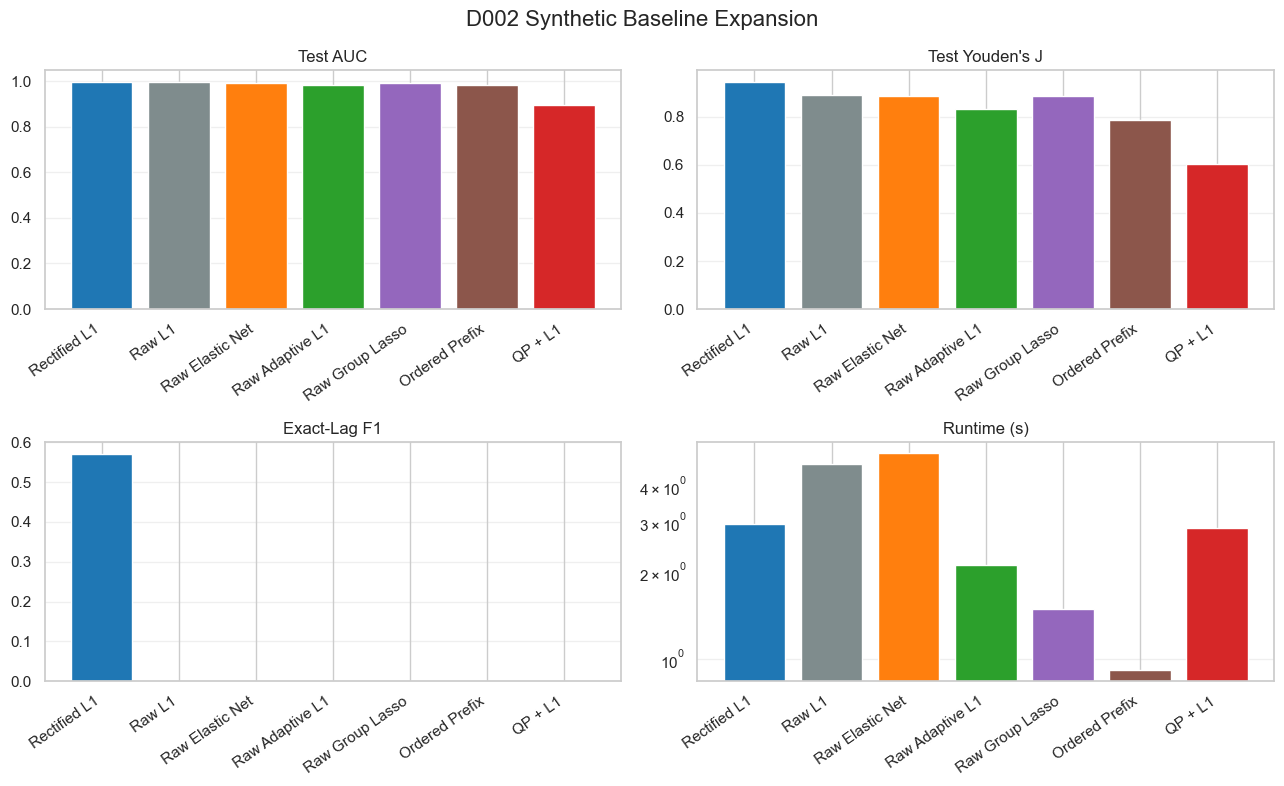

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\cross_domain_synthetic_benchmark.png


In [8]:
plot_metrics = [
    ("auc_test", "Test AUC"),
    ("j_test", "Test Youden's J"),
    ("lag_f1_exact", "Exact-Lag F1"),
    ("runtime_seconds", "Runtime (s)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()
x = np.arange(len(synthetic_runs))

for ax, (metric, title) in zip(axes, plot_metrics):
    ax.bar(
        x,
        synthetic_runs[metric].to_numpy(),
        color=[SYN_METHOD_COLORS[m] for m in synthetic_runs["method"]],
    )
    ax.set_xticks(x)
    ax.set_xticklabels(synthetic_runs["method_label"], rotation=35, ha="right")
    ax.set_title(title)
    if metric == "runtime_seconds":
        ax.set_yscale("log")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("D002 Synthetic Baseline Expansion", fontsize=16, y=0.98)
fig.tight_layout()
out_path = FIGURES_DIR / "cross_domain_synthetic_benchmark.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


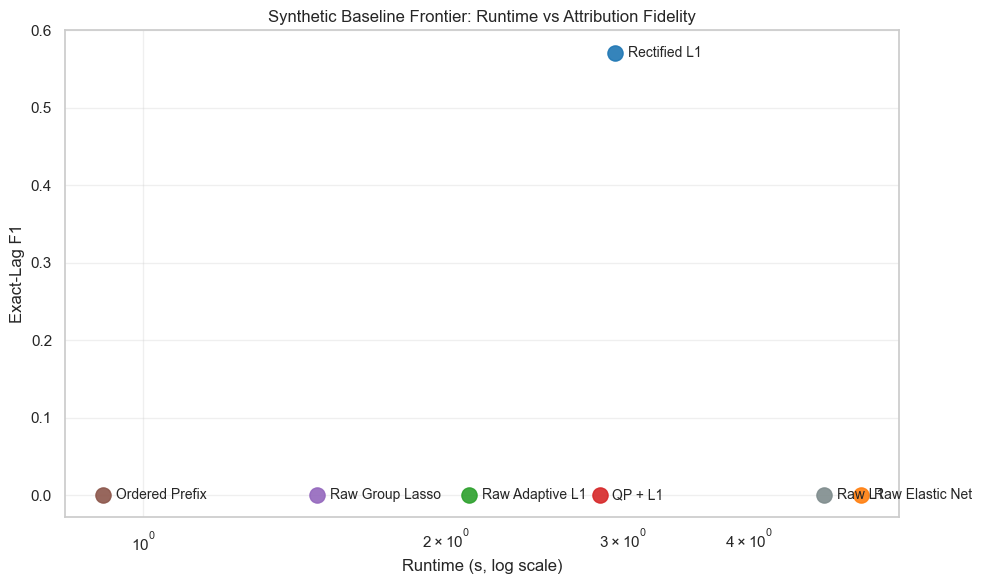

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\cross_domain_synthetic_frontier.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
for row in synthetic_runs.itertuples():
    ax.scatter(
        row.runtime_seconds,
        row.lag_f1_exact,
        s=120,
        color=SYN_METHOD_COLORS[row.method],
        alpha=0.9,
    )
    ax.text(row.runtime_seconds * 1.03, row.lag_f1_exact, row.method_label, fontsize=10, va="center")

ax.set_xscale("log")
ax.set_xlabel("Runtime (s, log scale)")
ax.set_ylabel("Exact-Lag F1")
ax.set_title("Synthetic Baseline Frontier: Runtime vs Attribution Fidelity")
ax.grid(True, alpha=0.3)
fig.tight_layout()
out_path = FIGURES_DIR / "cross_domain_synthetic_frontier.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


## Cross-Domain Transfer Panel

The second half of D002 asks whether the representation-first pattern transfers beyond the core synthetic comparison. This section evaluates a lighter core comparison, **raw L1 vs. rectified L1**, across multiple HAI attack subsets and the UCI ionosphere radar benchmark.

Important distinction:

- The HAI domains and the ionosphere row below are part of one **standardized generic transfer protocol** used for cross-domain comparison.
- The ionosphere result in this panel is **not** a replication of the 2022 Goose Bay case study.
- A separate section later in the notebook reconstructs the **published Goose Bay reference view** directly from the reported 2022 paper values and places it beside the generic probe so the two should not be conflated.


In [10]:
def prepare_cutlass_rectified_design(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    *,
    rectifier_kw: dict,
    duplicate_mode: str = "within_group",
) -> dict:
    rectifier = Rectifier(groups=None, **rectifier_kw)
    X_train_rect = rectifier.fit_transform(X_train, y_train)
    X_test_rect = rectifier.transform(X_test)
    consolidator = DuplicateColumnConsolidator(mode=duplicate_mode, expansion="split_evenly")
    X_train_fit = consolidator.fit_transform(X_train_rect, feature_names=rectifier.feature_names_)
    X_test_fit = consolidator.transform(X_test_rect, feature_names=rectifier.feature_names_)
    return {
        "rectifier": rectifier,
        "consolidator": consolidator,
        "X_train_fit": X_train_fit,
        "X_test_fit": X_test_fit,
        "rectified_feature_names": list(rectifier.feature_names_),
        "fit_feature_names": list(consolidator.feature_names_),
    }


def expanded_cutlass_coefficients(design: dict, coef_fit: np.ndarray) -> pd.Series:
    coef_fit_series = pd.Series(np.asarray(coef_fit).ravel(), index=design["fit_feature_names"], name="coef")
    coef_full = design["consolidator"].expand_coefficients(coef_fit_series)
    return pd.Series(np.asarray(coef_full).ravel(), index=design["rectified_feature_names"], name="coef")


def fit_cutlass_raw_fixed_l1(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    *,
    fixed_c: float,
    max_iter: int = 6000,
    tol: float = 1e-4,
) -> dict:
    start = perf_counter()
    scaler = SkStandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    lr = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=float(fixed_c),
        max_iter=max_iter,
        tol=tol,
        random_state=42,
    )
    lr.fit(X_train_scaled, y_train)
    prob = lr.predict_proba(X_test_scaled)[:, 1]
    metrics = {**metric_row(y_test, prob), **threshold_rates(y_test, prob)}
    coef = pd.Series(lr.coef_.ravel(), index=X_train.columns, name="coef")
    return {
        "coef": coef,
        "prob": prob,
        "metrics": {
            **metrics,
            "nonzero_total": int((coef != 0).sum()),
            "runtime_seconds": float(perf_counter() - start),
            "chosen_C": float(fixed_c),
        },
    }


def fit_cutlass_rectified_fixed_l1(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    *,
    fixed_c: float,
    rectifier_kw: dict,
    duplicate_mode: str,
    max_iter: int = 12000,
    tol: float = 1e-4,
) -> dict:
    start = perf_counter()
    design = prepare_cutlass_rectified_design(
        X_train,
        y_train,
        X_test,
        rectifier_kw=rectifier_kw,
        duplicate_mode=duplicate_mode,
    )
    lr = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=float(fixed_c),
        max_iter=max_iter,
        tol=tol,
        random_state=42,
    )
    lr.fit(design["X_train_fit"], y_train)
    prob = lr.predict_proba(design["X_test_fit"])[:, 1]
    metrics = {**metric_row(y_test, prob), **threshold_rates(y_test, prob)}
    coef = expanded_cutlass_coefficients(design, lr.coef_)
    return {
        "coef": coef,
        "prob": prob,
        "metrics": {
            **metrics,
            "nonzero_total": int((coef != 0).sum()),
            "runtime_seconds": float(perf_counter() - start),
            "chosen_C": float(fixed_c),
            "fit_features": int(design["X_train_fit"].shape[1]),
        },
    }


def load_or_cache_ionosphere() -> pd.DataFrame:
    if IONO_CACHE.exists():
        df = pd.read_csv(IONO_CACHE, header=None)
    else:
        df = pd.read_csv(IONO_URL, header=None)
        IONO_CACHE.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(IONO_CACHE, header=False, index=False)
    return df


def run_or_load_cross_domain_panel(overwrite_cache: bool = False) -> pd.DataFrame:
    cache_path = RUN_DIR / "cross_domain_transfer_runs.csv"
    if cache_path.exists() and not overwrite_cache:
        df = pd.read_csv(cache_path)
        required_columns = {
            "domain",
            "dataset_family",
            "method",
            "sample_train",
            "sample_test",
            "auc_test",
            "j_test",
            "f1max_test",
            "tpr_test",
            "tnr_test",
            "nonzero_total",
            "runtime_seconds",
            "chosen_C",
        }
        if required_columns.issubset(df.columns):
            print("Loaded cross-domain panel from:", cache_path)
            return df
        print("Cross-domain cache is missing required columns. Recomputing:", cache_path)

    rows = []

    for domain_label, spec in HAI_TARGETS.items():
        tag = spec["tag"]
        train_df = pd.read_parquet(PROCESSED_DIR / f"train_{tag}_sm_hai.parquet")
        test_df = pd.read_parquet(PROCESSED_DIR / f"test_{tag}_sm_hai.parquet")

        X_train = train_df.drop(columns=["INDC"])
        y_train = train_df["INDC"].astype(int).to_numpy()
        X_test = test_df.drop(columns=["INDC"])
        y_test = test_df["INDC"].astype(int).to_numpy()

        raw_result = fit_cutlass_raw_fixed_l1(X_train, y_train, X_test, y_test, fixed_c=RAW_HAI_C)
        rect_result = fit_cutlass_rectified_fixed_l1(
            X_train,
            y_train,
            X_test,
            y_test,
            fixed_c=RECT_HAI_C,
            rectifier_kw=HAI_RECTIFIER_KW,
            duplicate_mode=HAI_DUPLICATE_MODE,
        )

        rows.append(
            {
                "domain": domain_label,
                "dataset_family": "HAI",
                "method": "raw_l1",
                "sample_train": int(len(X_train)),
                "sample_test": int(len(X_test)),
                **raw_result["metrics"],
            }
        )
        rows.append(
            {
                "domain": domain_label,
                "dataset_family": "HAI",
                "method": "rectified_l1",
                "sample_train": int(len(X_train)),
                "sample_test": int(len(X_test)),
                **rect_result["metrics"],
            }
        )
        print(f"Completed HAI panel for {domain_label}")

    iono_raw = load_or_cache_ionosphere()
    X_iono = iono_raw.iloc[:, :-1].copy()
    X_iono.columns = [f"F{i:02d}" for i in range(X_iono.shape[1])]
    y_iono = (iono_raw.iloc[:, -1] == "g").astype(int).to_numpy()
    X_train, X_test, y_train, y_test = train_test_split(
        X_iono,
        y_iono,
        test_size=0.30,
        stratify=y_iono,
        random_state=42,
    )

    raw_result = fit_cutlass_raw_fixed_l1(X_train, y_train, X_test, y_test, fixed_c=IONO_RAW_C)
    rect_result = fit_cutlass_rectified_fixed_l1(
        X_train,
        y_train,
        X_test,
        y_test,
        fixed_c=IONO_RECT_C,
        rectifier_kw=IONO_RECTIFIER_KW,
        duplicate_mode="none",
    )

    rows.append(
        {
            "domain": "Ionosphere radar",
            "dataset_family": "Radar",
            "method": "raw_l1",
            "sample_train": int(len(X_train)),
            "sample_test": int(len(X_test)),
            **raw_result["metrics"],
        }
    )
    rows.append(
        {
            "domain": "Ionosphere radar",
            "dataset_family": "Radar",
            "method": "rectified_l1",
            "sample_train": int(len(X_train)),
            "sample_test": int(len(X_test)),
            **rect_result["metrics"],
        }
    )

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    print("Saved cross-domain panel to:", cache_path)
    return df


cross_domain_runs = run_or_load_cross_domain_panel(overwrite_cache=OVERWRITE_CACHE)
if display is not None:
    display(cross_domain_runs)
else:
    print(cross_domain_runs.to_string(index=False))


Loaded cross-domain panel from: C:\Users\jason\ODU\dissertation\notebooks\runs_new\cross_domain\cross_domain_transfer_runs.csv


,domain,dataset_family,method,sample_train,sample_test,auc_test,j_test,f1max_test,tp,tn,fp,fn,tpr_test,tnr_test,nonzero_total,runtime_seconds,chosen_C,fit_features
0,HAI attack_p2 (a1),HAI,raw_l1,2552,1080,0.949228,0.574074,0.883268,519,331,209,21,0.961111,0.612963,26,37.460283,0.012,NaN
1,HAI attack_p2 (a1),HAI,rectified_l1,2552,1080,0.989491,0.929630,0.966950,513,529,11,27,0.950000,0.979630,57,0.645197,0.012,459.0
2,HAI attack_p1p2 (a2),HAI,raw_l1,2438,5638,0.999955,0.874069,0.996276,2819,2464,355,0,1.000000,0.874069,50,22.121753,0.012,NaN
3,HAI attack_p1p2 (a2),HAI,rectified_l1,2438,5638,0.999313,0.989003,0.994660,2795,2812,7,24,0.991486,0.997517,47,24.261717,0.012,464.0
4,HAI attack_p3 (a3),HAI,raw_l1,1158,182,0.551503,-0.065934,0.756303,21,64,27,70,0.230769,0.703297,57,11.642162,0.012,NaN
5,HAI attack_p3 (a3),HAI,rectified_l1,1158,182,0.730407,-0.065934,0.784314,1,84,7,90,0.010989,0.923077,41,0.311465,0.012,460.0
6,HAI attack_p1p3 (a4),HAI,raw_l1,1236,724,0.940730,0.765193,0.904564,305,334,28,57,0.842541,0.922652,27,5.428328,0.012,NaN
7,HAI attack_p1p3 (a4),HAI,rectified_l1,1236,724,0.928127,0.712707,0.859624,310,310,52,52,0.856354,0.856354,51,0.479976,0.012,455.0
8,Ionosphere radar,Radar,raw_l1,245,106,0.959365,0.774768,0.950355,67,30,8,1,0.985294,0.789474,9,0.007775,0.100,NaN
9,Ionosphere radar,Radar,rectified_l1,245,106,0.919505,0.715944,0.919708,63,30,8,5,0.926471,0.789474,10,0.009376,0.100,34.0


In [11]:
domain_order = list(HAI_TARGETS.keys()) + ["Ionosphere radar"]
summary_rows = []
for domain in domain_order:
    domain_df = cross_domain_runs[cross_domain_runs["domain"] == domain].set_index("method")
    raw_row = domain_df.loc["raw_l1"]
    rect_row = domain_df.loc["rectified_l1"]
    summary_rows.append(
        {
            "domain": domain,
            "dataset_family": raw_row["dataset_family"],
            "sample_train": int(raw_row["sample_train"]),
            "sample_test": int(raw_row["sample_test"]),
            "raw_auc": float(raw_row["auc_test"]),
            "rectified_auc": float(rect_row["auc_test"]),
            "delta_auc": float(rect_row["auc_test"] - raw_row["auc_test"]),
            "raw_j": float(raw_row["j_test"]),
            "rectified_j": float(rect_row["j_test"]),
            "delta_j": float(rect_row["j_test"] - raw_row["j_test"]),
            "raw_tpr": float(raw_row["tpr_test"]),
            "rectified_tpr": float(rect_row["tpr_test"]),
            "raw_tnr": float(raw_row["tnr_test"]),
            "rectified_tnr": float(rect_row["tnr_test"]),
            "raw_nonzero": int(raw_row["nonzero_total"]),
            "rectified_nonzero": int(rect_row["nonzero_total"]),
            "raw_runtime": float(raw_row["runtime_seconds"]),
            "rectified_runtime": float(rect_row["runtime_seconds"]),
        }
    )

transfer_summary = pd.DataFrame(summary_rows)
transfer_summary.to_csv(RUN_DIR / "cross_domain_transfer_summary.csv", index=False)

transfer_summary_formatted = transfer_summary.copy()
for column in [
    "raw_auc",
    "rectified_auc",
    "delta_auc",
    "raw_j",
    "rectified_j",
    "delta_j",
    "raw_tpr",
    "rectified_tpr",
    "raw_tnr",
    "rectified_tnr",
    "raw_runtime",
    "rectified_runtime",
]:
    transfer_summary_formatted[column] = transfer_summary_formatted[column].map(lambda value: format_numeric(value, 3))
transfer_summary_formatted.to_csv(RUN_DIR / "cross_domain_transfer_summary_formatted.csv", index=False)

if display is not None:
    display(transfer_summary_formatted)
else:
    print(transfer_summary_formatted.to_string(index=False))


,domain,dataset_family,sample_train,sample_test,raw_auc,rectified_auc,delta_auc,raw_j,rectified_j,delta_j,raw_tpr,rectified_tpr,raw_tnr,rectified_tnr,raw_nonzero,rectified_nonzero,raw_runtime,rectified_runtime
0,HAI attack_p2 (a1),HAI,2552,1080,0.949,0.989,0.040,0.574,0.930,0.356,0.961,0.950,0.613,0.980,26,57,37.460,0.645
1,HAI attack_p1p2 (a2),HAI,2438,5638,1.000,0.999,-0.001,0.874,0.989,0.115,1.000,0.991,0.874,0.998,50,47,22.122,24.262
2,HAI attack_p3 (a3),HAI,1158,182,0.552,0.730,0.179,-0.066,-0.066,0.000,0.231,0.011,0.703,0.923,57,41,11.642,0.311
3,HAI attack_p1p3 (a4),HAI,1236,724,0.941,0.928,-0.013,0.765,0.713,-0.052,0.843,0.856,0.923,0.856,27,51,5.428,0.480
4,Ionosphere radar,Radar,245,106,0.959,0.920,-0.040,0.775,0.716,-0.059,0.985,0.926,0.789,0.789,9,10,0.008,0.009


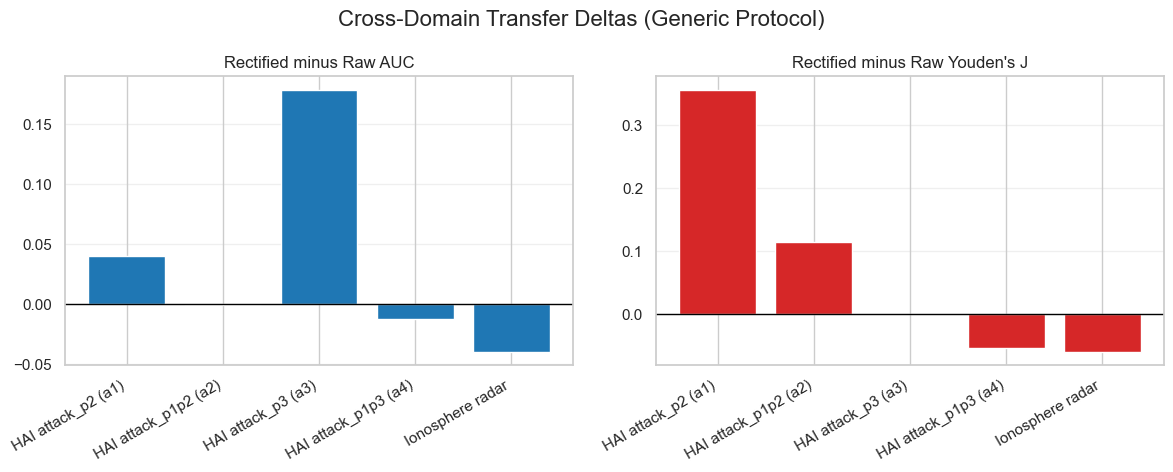

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\cross_domain_transfer_deltas.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
x = np.arange(len(transfer_summary))

axes[0].bar(x, transfer_summary["delta_auc"].to_numpy(), color="#1f77b4")
axes[0].axhline(0.0, color="black", linewidth=1.0)
axes[0].set_title("Rectified minus Raw AUC")
axes[0].set_xticks(x)
axes[0].set_xticklabels(transfer_summary["domain"], rotation=30, ha="right")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(x, transfer_summary["delta_j"].to_numpy(), color="#d62728")
axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].set_title("Rectified minus Raw Youden's J")
axes[1].set_xticks(x)
axes[1].set_xticklabels(transfer_summary["domain"], rotation=30, ha="right")
axes[1].grid(True, axis="y", alpha=0.3)

fig.suptitle("Cross-Domain Transfer Deltas (Generic Protocol)", fontsize=16, y=0.98)
fig.tight_layout()
out_path = FIGURES_DIR / "cross_domain_transfer_deltas.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


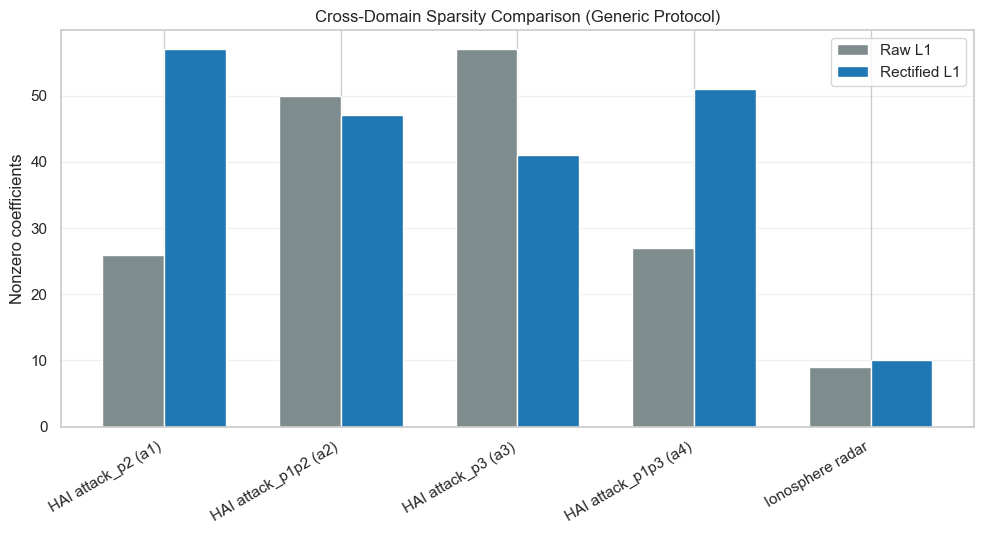

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\cross_domain_sparsity.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(transfer_summary))
width = 0.35
ax.bar(x - width / 2, transfer_summary["raw_nonzero"].to_numpy(), width=width, label="Raw L1", color="#7f8c8d")
ax.bar(x + width / 2, transfer_summary["rectified_nonzero"].to_numpy(), width=width, label="Rectified L1", color="#1f77b4")
ax.set_xticks(x)
ax.set_xticklabels(transfer_summary["domain"], rotation=30, ha="right")
ax.set_ylabel("Nonzero coefficients")
ax.set_title("Cross-Domain Sparsity Comparison (Generic Protocol)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
out_path = FIGURES_DIR / "cross_domain_sparsity.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


## Ionosphere Protocol Distinction

The ionosphere dataset appears in this notebook for two different reasons:

1. **Published Goose Bay reference view**: the values reported in the 2022 paper, retained for continuity with the original publication.
2. **Generic transfer probe**: the standardized `cutlass`-based protocol used in this notebook so ionosphere can participate in the same D002 transfer panel as the HAI domains.

These are not the same experiment. The published Goose Bay view uses the original LLE study protocol, while the generic transfer probe uses the standardized cross-domain notebook protocol. The comparison below keeps both views visible while preventing the negative delta in the generic probe from being misread as a contradiction of the published result.


In [14]:
generic_ionosphere = cross_domain_runs[cross_domain_runs["domain"] == "Ionosphere radar"].copy()
generic_ionosphere["view"] = "Generic transfer probe"
generic_ionosphere["source"] = "cross_domain.ipynb standardized protocol"
generic_ionosphere["notes"] = "70/30 stratified split, random_state=42, fixed-C cutlass sparse logistic"

published_rows = []
for method, rates in PUBLISHED_GOOSE_BAY.items():
    published_rows.append(
        {
            "view": "Published 2022 Goose Bay reference",
            "source": "orender2022 paper",
            "notes": "Original LLE R pipeline, 67/33 class-stratified split, rseed=2345",
            "method": method,
            "dataset_family": "Radar",
            "domain": "Ionosphere radar",
            "sample_train": np.nan,
            "sample_test": np.nan,
            "auc_test": np.nan,
            "j_test": float(rates["tpr_test"] + rates["tnr_test"] - 1.0),
            "f1max_test": np.nan,
            "tpr_test": float(rates["tpr_test"]),
            "tnr_test": float(rates["tnr_test"]),
            "nonzero_total": np.nan,
            "runtime_seconds": np.nan,
            "chosen_C": np.nan,
            "fit_features": np.nan,
        }
    )

published_ionosphere = pd.DataFrame(published_rows)
ionosphere_protocol_comparison = pd.concat([published_ionosphere, generic_ionosphere], ignore_index=True, sort=False)
ionosphere_protocol_comparison["method_label"] = ionosphere_protocol_comparison["method"].map(
    {"raw_l1": "Raw L1", "rectified_l1": "Rectified L1"}
)
ionosphere_protocol_comparison = ionosphere_protocol_comparison[
    ["view", "method", "method_label", "tpr_test", "tnr_test", "j_test", "auc_test", "source", "notes"]
].copy()
ionosphere_protocol_comparison.to_csv(RUN_DIR / "ionosphere_protocol_comparison.csv", index=False)

ionosphere_protocol_table = ionosphere_protocol_comparison.copy()
for column in ["tpr_test", "tnr_test", "j_test", "auc_test"]:
    ionosphere_protocol_table[column] = ionosphere_protocol_table[column].map(lambda value: format_numeric(value, 3))
ionosphere_protocol_table.to_csv(RUN_DIR / "ionosphere_protocol_comparison_formatted.csv", index=False)

if display is not None:
    display(ionosphere_protocol_table)
else:
    print(ionosphere_protocol_table.to_string(index=False))


,view,method,method_label,tpr_test,tnr_test,j_test,auc_test,source,notes
0,Published 2022 Goose Bay reference,rectified_l1,Rectified L1,0.973,0.881,0.854,n/a,orender2022 paper,"Original LLE R pipeline, 67/33 class-stratifie..."
1,Published 2022 Goose Bay reference,raw_l1,Raw L1,0.933,0.762,0.695,n/a,orender2022 paper,"Original LLE R pipeline, 67/33 class-stratifie..."
2,Generic transfer probe,raw_l1,Raw L1,0.985,0.789,0.775,0.959,cross_domain.ipynb standardized protocol,"70/30 stratified split, random_state=42, fixed..."
3,Generic transfer probe,rectified_l1,Rectified L1,0.926,0.789,0.716,0.920,cross_domain.ipynb standardized protocol,"70/30 stratified split, random_state=42, fixed..."


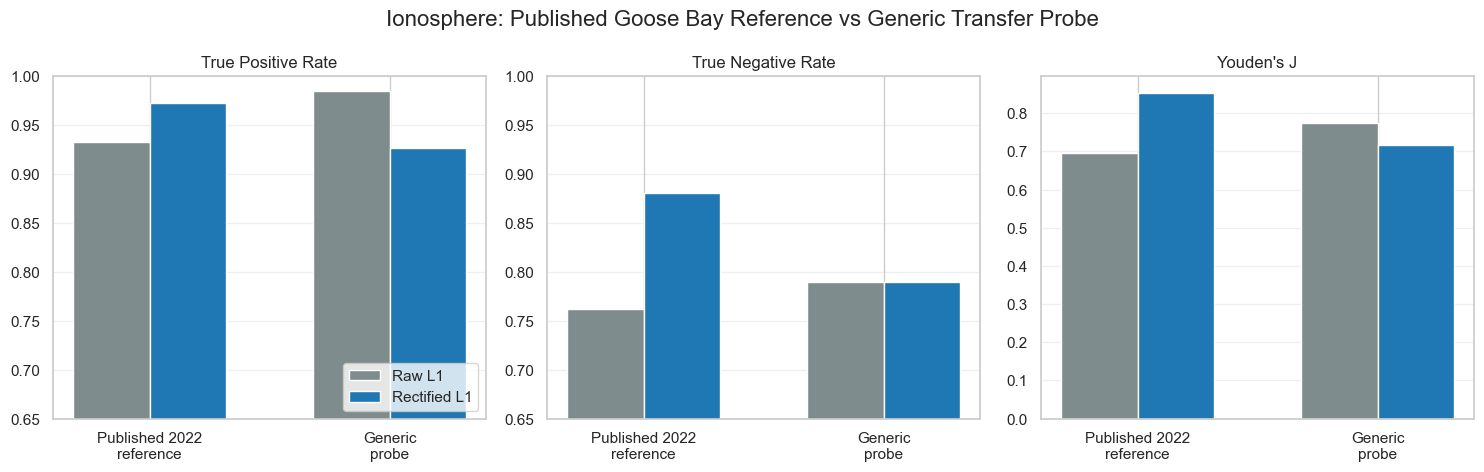

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\cross_domain_ionosphere_protocol_comparison.png


In [15]:
view_order = ["Published 2022 Goose Bay reference", "Generic transfer probe"]
method_order = ["raw_l1", "rectified_l1"]
method_colors = {"raw_l1": "#7f8c8d", "rectified_l1": "#1f77b4"}
metric_specs = [
    ("tpr_test", "True Positive Rate"),
    ("tnr_test", "True Negative Rate"),
    ("j_test", "Youden's J"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
x = np.arange(len(view_order))
width = 0.32

for ax, (metric, title) in zip(axes, metric_specs):
    for offset, method in [(-width / 2, "raw_l1"), (width / 2, "rectified_l1")]:
        values = []
        for view in view_order:
            row = ionosphere_protocol_comparison[
                (ionosphere_protocol_comparison["view"] == view)
                & (ionosphere_protocol_comparison["method"] == method)
            ].iloc[0]
            values.append(float(row[metric]))
        ax.bar(
            x + offset,
            values,
            width=width,
            color=method_colors[method],
            label={"raw_l1": "Raw L1", "rectified_l1": "Rectified L1"}[method] if metric == "tpr_test" else None,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(["Published 2022\nreference", "Generic\nprobe"])
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    if metric in {"tpr_test", "tnr_test"}:
        ax.set_ylim(0.65, 1.0)

axes[0].legend(loc="lower right")
fig.suptitle("Ionosphere: Published Goose Bay Reference vs Generic Transfer Probe", fontsize=16, y=0.98)
fig.tight_layout()
out_path = FIGURES_DIR / "cross_domain_ionosphere_protocol_comparison.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


In [16]:
takeaways = domain_transfer_takeaways(transfer_summary)
takeaways_path = RUN_DIR / "cross_domain_takeaways.txt"
takeaways_path.write_text("\n".join(takeaways) + "\n", encoding="utf-8")

print("Transferability summary for the standardized generic protocol:")
for line in takeaways:
    print("-", line)
print("Saved:", takeaways_path)


Transferability summary for the standardized generic protocol:
- Under the standardized generic protocol, rectification improves both AUC and J on: HAI attack_p2 (a1)
- Under the standardized generic protocol, rectification is mixed across metrics on: HAI attack_p1p2 (a2), HAI attack_p3 (a3)
- Under the standardized generic protocol, rectification does not dominate on: HAI attack_p1p3 (a4), Ionosphere radar
Saved: C:\Users\jason\ODU\dissertation\notebooks\runs_new\cross_domain\cross_domain_takeaways.txt


## Artifact Summary

The notebook writes the core artifacts to:

- `notebooks/runs_new/cross_domain/synthetic_baseline_runs.csv`
- `notebooks/runs_new/cross_domain/synthetic_baseline_summary.csv`
- `notebooks/runs_new/cross_domain/synthetic_baseline_summary_formatted.csv`
- `notebooks/runs_new/cross_domain/cross_domain_transfer_runs.csv`
- `notebooks/runs_new/cross_domain/cross_domain_transfer_summary.csv`
- `notebooks/runs_new/cross_domain/cross_domain_transfer_summary_formatted.csv`
- `notebooks/runs_new/cross_domain/ionosphere_protocol_comparison.csv`
- `notebooks/runs_new/cross_domain/ionosphere_protocol_comparison_formatted.csv`
- `notebooks/runs_new/cross_domain/cross_domain_takeaways.txt`

and saves figures into `notebooks/Figures/`:

- `cross_domain_synthetic_benchmark.png`
- `cross_domain_synthetic_frontier.png`
- `cross_domain_transfer_deltas.png`
- `cross_domain_sparsity.png`
- `cross_domain_ionosphere_protocol_comparison.png`
